In [1]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import MDAnalysis as mda
import pandas as pd
import yaml
import freesasa
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings
freesasa.setVerbosity(0)

/Users/chloehjj/PCE26/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
scaffolds = yaml.safe_load(open("../data/scaffolds/index.yaml"))

In [3]:
def compute_sasa(
    pdb_path: str
) -> dict[str, list[dict]]:
    structure = freesasa.Structure(pdb_path)
    result = freesasa.calc(structure)
    residue_areas = result.residueAreas()

    out = []

    for chain_label, residues in residue_areas.items():
        for res_number, area in residues.items():

            entry = {
                "chain": chain_label,
                "residue_number": res_number,
                "residue_type": area.residueType,
                "sasa_total": round(area.total, 2),
                "sasa_side_chain": round(area.sideChain, 2),
                "relative_side_chain": round(area.relativeSideChain, 3),
            }
            out.append(entry)

    return pd.DataFrame.from_records(out)

sasa_df = []
for item in scaffolds:
    tmp_df = compute_sasa('../data/scaffolds/' + item["scaffold"])
    tmp_df['scaffold'] = item['name']
    sasa_df.append(tmp_df)
    
sasa_df = pd.concat(sasa_df)
sasa_df 

,chain,residue_number,residue_type,sasa_total,sasa_side_chain,relative_side_chain,scaffold
0,A,217,GLY,90.78,0.00,NaN,adenovirus
1,A,218,ALA,70.23,39.36,0.607,adenovirus
2,A,219,ASP,72.80,59.63,0.594,adenovirus
3,A,220,GLY,33.84,0.00,NaN,adenovirus
4,A,221,VAL,21.91,16.85,0.153,adenovirus
...,...,...,...,...,...,...,...
313,C,166,A,26.96,1.74,NaN,stmv
314,C,167,A,29.16,8.05,NaN,stmv
315,C,168,A,63.45,31.69,NaN,stmv
316,C,169,A,42.17,16.02,NaN,stmv


In [4]:
amino_acid_properties = {
    "ALA": "Nonpolar",
    "VAL": "Nonpolar",
    "LEU": "Nonpolar",
    "ILE": "Nonpolar",
    "PHE": "Nonpolar",
    "TRP": "Nonpolar",
    "MET": "Nonpolar",
    "PRO": "Nonpolar",
    "GLY": "Nonpolar",
    "SER": "Polar",
    "THR": "Polar",
    "CYS": "Polar",
    "TYR": "Polar",
    "ASN": "Polar",
    "GLN": "Polar",
    "LYS": "Basic",
    "ARG": "Basic",
    "HIS": "Basic",
    "ASP": "Acidic",
    "GLU": "Acidic"
}

sasa_df['residue_family'] = sasa_df['residue_type'].map(amino_acid_properties)

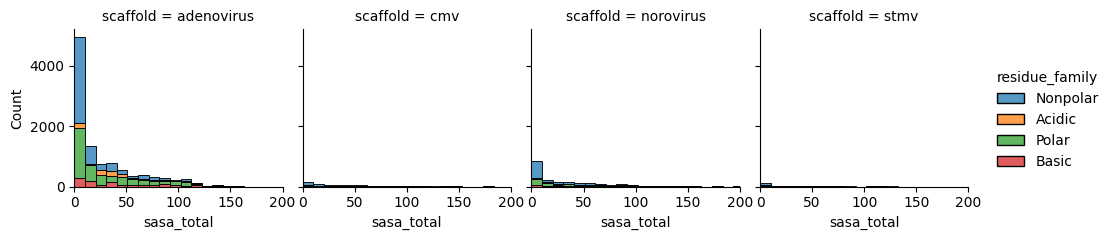

In [5]:
sns.displot(data=sasa_df, 
            x = 'sasa_total',
            bins = 20,
            col = 'scaffold',
            hue = 'residue_family',
            multiple = 'stack',
            height = 2.5,
            aspect = 1).set(xlim = (0,200))

In [6]:
def compute_distance_to_center(
    pdb_path: str
) -> dict[str, list[dict]]:
    """Return exposed GLU/ASP and LYS residues sorted by SASA (descending)."""
    structure = mda.Universe(pdb_path)
    positions = structure.atoms.select_atoms("name CA").positions
    distances = np.linalg.norm(positions, axis=1)
    resnums = structure.atoms.select_atoms("name CA").resnums
    resnames = structure.atoms.select_atoms("name CA").resnames
    chids = structure.atoms.select_atoms("name CA").chainIDs
    u = pd.DataFrame.from_dict(
        dict(chain=chids, residue_number=resnums, residue_type=resnames, distance=distances)
    )
    u.residue_number = u.residue_number.astype(str)
    return u

distances_df = []
for item in scaffolds:
    tmp_df = compute_distance_to_center('../data/scaffolds/' + item["scaffold"])
    tmp_df['scaffold'] = item['name']
    distances_df.append(tmp_df)
distances_df = pd.concat(distances_df)
distances_df

,chain,residue_number,residue_type,distance,scaffold
0,A,217,GLY,84.028557,adenovirus
1,A,218,ALA,85.262695,adenovirus
2,A,219,ASP,86.550697,adenovirus
3,A,220,GLY,89.306755,adenovirus
4,A,221,VAL,93.032272,adenovirus
...,...,...,...,...,...
9595,A,156,CYS,66.706810,stmv
9596,A,157,CYS,66.450211,stmv
9597,A,157,CYS,66.423355,stmv
9598,A,158,PHE,69.634506,stmv


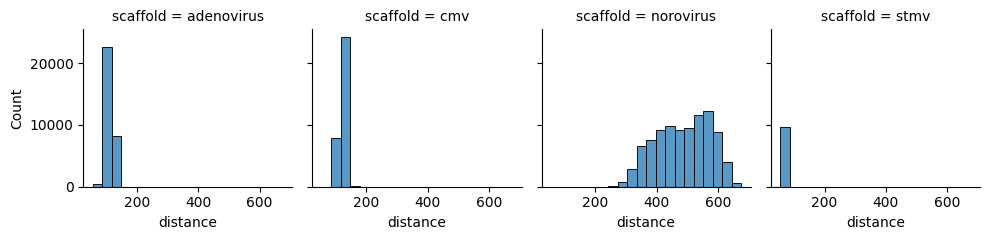

In [7]:
sns.displot(data = distances_df,
            x = 'distance',
            bins = 20,
            col = 'scaffold',
            multiple = 'stack',
            height = 2.5,
            aspect = 1)

In [8]:
full_df = pd.merge(distances_df, sasa_df)

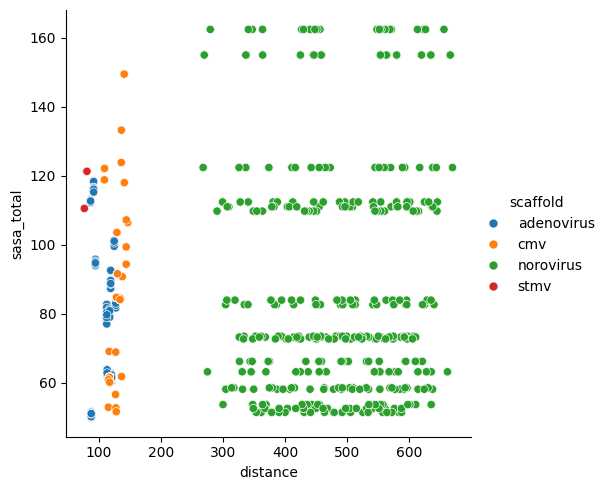

In [9]:
sns.relplot(full_df.query('residue_type == "LYS"').query('sasa_total > 50'),
            x = 'distance', 
            y = 'sasa_total',
            hue = 'scaffold')

In [10]:
full_df = pd.merge(
    full_df,
    full_df.groupby('scaffold', as_index=False)['distance'].mean(),
    suffixes = ['','_mean'], 
    on = ['scaffold']
)
full_df['distance_norm'] = full_df['distance'] - full_df['distance_mean']

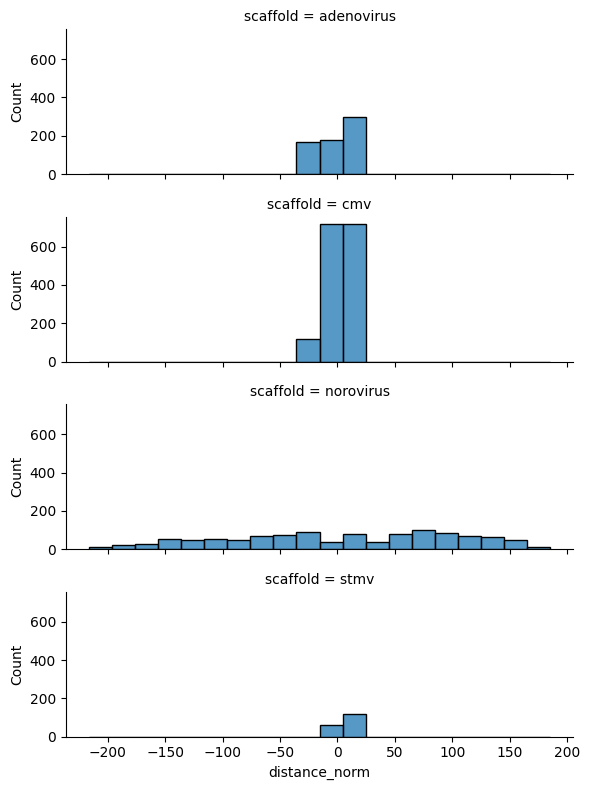

In [11]:
sns.displot(full_df.query('residue_type == "LYS"').query('sasa_total > 50'),
            x = 'distance_norm',
            row = 'scaffold',
            bins = 20,
            multiple = 'stack',
            height = 2,
            aspect = 3)

In [12]:
full_df['location'] = full_df['distance_norm'].apply(lambda x: 'outer' if x > 0 else 'inner')
full_df

,chain,residue_number,residue_type,distance,scaffold,sasa_total,sasa_side_chain,relative_side_chain,residue_family,distance_mean,distance_norm,location
0,A,217,GLY,84.028557,adenovirus,90.78,0.00,NaN,Nonpolar,109.361946,-25.333389,inner
1,A,218,ALA,85.262695,adenovirus,70.23,39.36,0.607,Nonpolar,109.361946,-24.099251,inner
2,A,219,ASP,86.550697,adenovirus,72.80,59.63,0.594,Acidic,109.361946,-22.811249,inner
3,A,220,GLY,89.306755,adenovirus,33.84,0.00,NaN,Nonpolar,109.361946,-20.055191,inner
4,A,221,VAL,93.032272,adenovirus,21.91,16.85,0.153,Nonpolar,109.361946,-16.329674,inner
...,...,...,...,...,...,...,...,...,...,...,...,...
166195,A,156,CYS,66.706810,stmv,0.00,0.00,0.000,Polar,73.082863,-6.376053,inner
166196,A,157,CYS,66.450211,stmv,3.29,3.29,0.037,Polar,73.082863,-6.632652,inner
166197,A,157,CYS,66.423355,stmv,3.29,3.29,0.037,Polar,73.082863,-6.659508,inner
166198,A,158,PHE,69.634506,stmv,0.00,0.00,0.000,Nonpolar,73.082863,-3.448357,inner


In [13]:
u = mda.Universe('../data/scaffolds/' + scaffolds[0]["scaffold"])

In [14]:
u.atoms.occupancies = 0.0
x = scaffolds[0]['name']
for k, item in full_df.query('scaffold == @x').iterrows():

    selection = u.select_atoms('chainID {0} and resnum {1}'.format(item.chain, item.residue_number))
    if item.location == 'inner':
        selection.atoms.occupancies = -1
    if item.location == 'outer':
        selection.atoms.occupancies = 1
u

<Universe with 250560 atoms>

In [15]:
u.atoms.write("fooo.pdb")

In [16]:
full_df.query('residue_type == "LYS"').query('sasa_total > 50').to_csv('../data/scaffolds/lysine-choices.csv')